In [4]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt
from matplotlib import cm

def integrand(x, grain, rim):
    a = grain + rim
    return np.sqrt(2*a*(x+a) - (x+a)**2) - np.sqrt(2*grain*(x+grain) - (x+grain)**2)


rim = 0.3

grain = 1.0

I = quad(integrand, 0, 1, args=(grain, rim))
z = I[0]/(rim) * 100 - 100
print(I[0], z)

0.37153580398778596 23.84526799592865


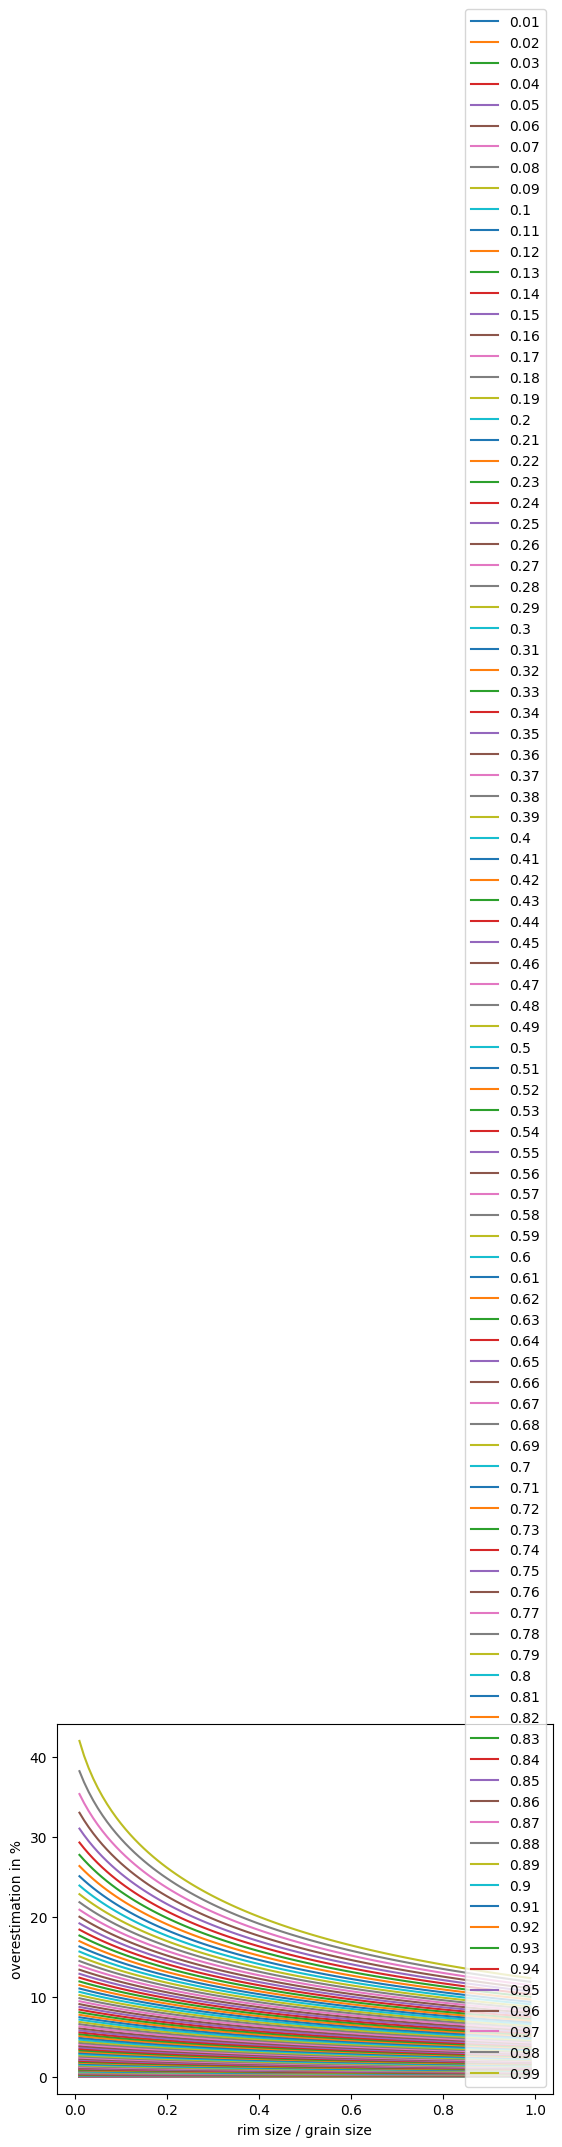

In [2]:
grain = 1.0
i_start = 0
i_stop  = 1
results = {}
steps = 100
X = []
Y = []
Z = []
for j in range(1,100,1):
	i_stop = j/100
	x_line = []
	y_line = []
	z_line = []
	for i in range(1, steps):
		rim = i/steps
		I = quad(integrand, i_start, i_stop, args=(grain, rim))
		z = I[0]/(rim*(i_stop-i_start)) * 100 - 100
		results[rim] = z
		x_line.append(rim)
		y_line.append(i_stop)
		z_line.append(z)
	X.append(x_line)
	Y.append(y_line)
	Z.append(z_line)

	plt.plot(results.keys(), results.values(), label=i_stop)

X = np.array(X)
Y = np.array(Y)
Z = np.array(Z)

plt.legend(loc='lower right')
plt.xlabel('rim size / grain size')
plt.ylabel('overestimation in %')
plt.show()

<>:23: SyntaxWarning: invalid escape sequence '\%'
<>:25: SyntaxWarning: invalid escape sequence '\%'
<>:23: SyntaxWarning: invalid escape sequence '\%'
<>:25: SyntaxWarning: invalid escape sequence '\%'
C:\Users\Florian Kleiner\AppData\Local\Temp\ipykernel_206196\2969034827.py:23: SyntaxWarning: invalid escape sequence '\%'
  fig.colorbar(surf, shrink=0.75, aspect=20, pad=0.00, label='overestimation in \%')
C:\Users\Florian Kleiner\AppData\Local\Temp\ipykernel_206196\2969034827.py:25: SyntaxWarning: invalid escape sequence '\%'
  ax.set_zlabel('overestimation in \%', rotation=90)


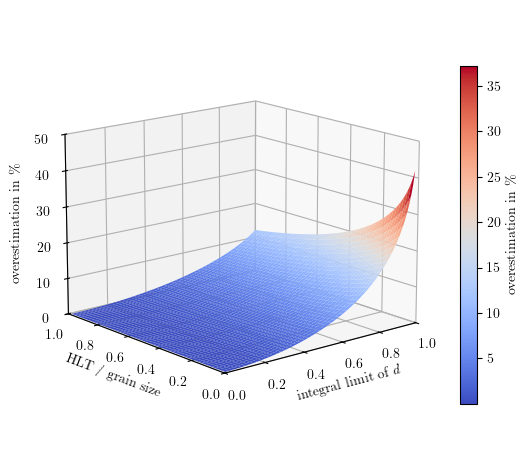

In [16]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Roman"
})

fig = plt.figure()#figsize=(12, 4)
ax = fig.add_subplot(projection='3d')

ax.invert_yaxis()
ax.view_init(elev=15, azim=-130)

# Plot a basic wireframe.
surf = ax.plot_surface(Y, X, Z, cmap=cm.coolwarm, antialiased=True)

#ax.plot_wireframe(X, Y, Z, rstride=1, cstride=10)
#ax.plot_wireframe(X, Y, Z, linewidth=.5, rstride=1, cstride=10, alpha=0.7, edgecolor='royalblue')
#ax.contourf(X, Y, Z, zdir='x', offset=0, cmap='coolwarm')
#ax.contourf(X, Y, Z, zdir='y', offset=1, cmap='coolwarm')
#ax.contourf(X, Y, Z, zdir='z', offset=0, cmap='coolwarm')

ax.set(xlim=(0,1), ylim=(0,1), zlim=(0,50),
       xlabel='integral limit of $i$', ylabel='HLT / grain size')
fig.colorbar(surf, shrink=0.75, aspect=20, pad=0.00, label='overestimation in \%')
ax.zaxis.set_rotate_label(False)  # disable automatic rotation
ax.set_zlabel('overestimation in \%', rotation=90)
ax.set_box_aspect(aspect=None, zoom=0.86)
plt.tight_layout()
plt.savefig('../sectioning_overestimation.svg')
plt.savefig('../sectioning_overestimation.pdf')
plt.show()